In [1]:
# Import packages
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from pathlib import Path

# Pathways 
out_dir = Path("..") / "plots" / "eda"
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / "black.pdf"

In [2]:
""" Global parameters """

# Answer to the universe and everything
np.random.seed(42)

In [3]:
""" Defining the analytical Black-Scholes model """

def bs(S, K, T, r, sigma, type="call"):
    
    # Preventing division ny zero if T is 0
    T = np.maximum(T, 1e-10)

    # Calculating d1 and d2 
    d1 = (np.log(S/K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)

    # Calculating prices depending on call or put,
    # while raising error if user selects neither
    if type == "call":
        price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    elif type == "put":
        price = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)
    else:
        raise ValueError("do either call or put option type")
    
    # Returning the analytically sound price of the option
    return price


In [4]:
""" Calculating prices """

# Input values
strike = 100.0  
maturity = 1.0
rf = 0.05
volatility = 0.20

# Generating an array of underlying asset prices
S_values = np.linspace(50, 150, 100)

# Calculating call and put prices
call = bs(S=S_values, K=strike, T=maturity, r=rf, sigma=volatility, type="call")
put = bs(S=S_values, K=strike, T=maturity, r=rf, sigma=volatility, type="put")

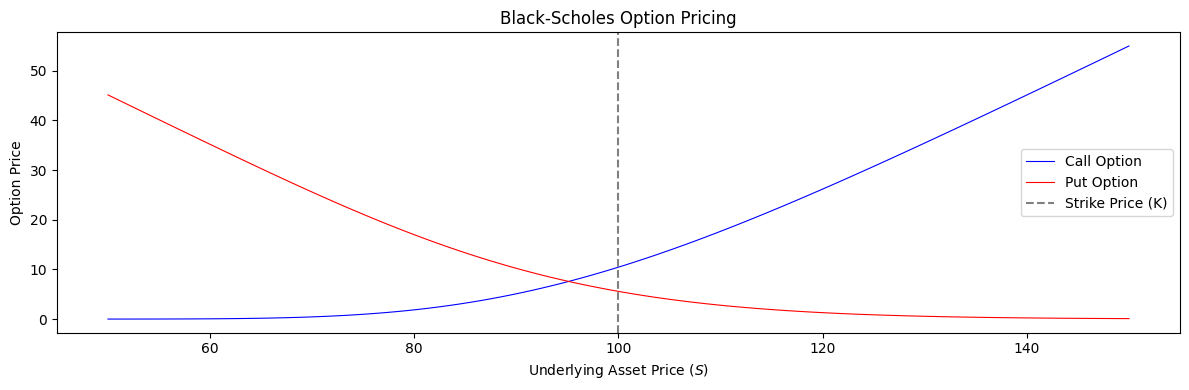

In [5]:
""" Plotting """

# Setting up the figure plotting
plt.figure(figsize=(12,4))

# Plotting the call and put options
plt.plot(S_values, call, label="Call Option", color="blue", lw=0.8)
plt.plot(S_values, put, label="Put Option", color="red", lw=0.8)

# Inserting the strike price
plt.axvline(x=strike, color="gray", linestyle="--", label="Strike Price (K)")

# Adding title, axes titles, and legend
plt.title("Black-Scholes Option Pricing")
plt.xlabel("Underlying Asset Price ($S$)")
plt.ylabel("Option Price")
plt.legend()

# Tight layout
plt.tight_layout()

# # Saving and showing the figure
plt.savefig(out_path, bbox_inches="tight")
plt.show()